 25%|██▌       | 1/4 [08:22<25:07, 502.57s/it]/home/yu/XRT/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/yu/XRT/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/yu/XRT/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
100%|██████████| 4/4 [1:03:09<00:00, 947.35s/it]


[array(1.74295397e+46), array(1.11270689e+46), array(8.90715287e+45), array(8.53381982e+45), array(6.56074792e+45), array(4.95138799e+45), array(4.89382793e+45), array(4.45014392e+45), array(3.51177842e+45), array(3.48807733e+45), array(4.12527582e+45), array(3.98629934e+45), array(3.16073554e+45), array(3.50041198e+45)]
[[np.float64(309.8609265810119), np.float64(312.84937063585494), np.float64(319.78754610079886), np.float64(333.51086520769877), np.float64(351.2158043485124), np.float64(362.3282632210312), np.float64(378.428489535072), np.float64(408.83563606873304), np.float64(408.66901922804664), np.float64(429.0947925542896), np.float64(438.7778777077383), np.float64(459.1778186893371), np.float64(1835.4186462542239)], [np.float64(313.0748517823249), np.float64(319.93346236027355), np.float64(334.97553797560704), np.float64(363.1065301238568), np.float64(384.08494991859334), np.float64(413.596579391492), np.float64(424.5858603185079), np.float64(450.90691793848964), np.float64(490

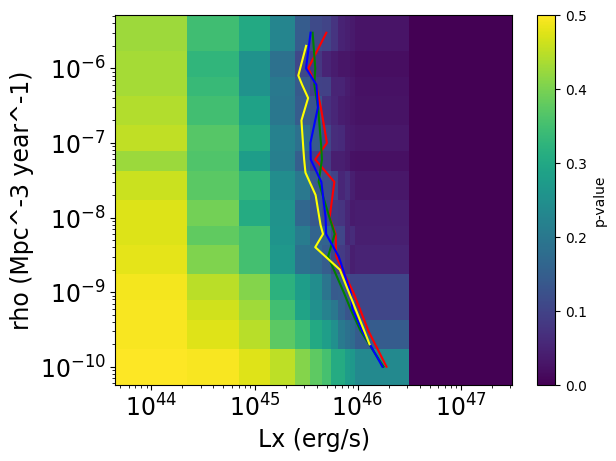

In [1]:
import numpy as np
from pathlib import Path
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
base_dir = '/home/yu/XRT/MultipleTiling'
Gamma_list = [3,5,7,10]
rho_list_3 = np.sort(np.array([2e-6, 2e-7, 4e-7, 6e-7, 8e-7, 2e-8, 4e-8, 6e-8, 8e-8, 2e-9, 4e-9, 6e-9, 8e-9, 2e-10]))[::-1]
rho_list_other = np.array([1e-10, 3e-10, 6e-10, 1e-9, 3e-9, 6e-9, 1e-8, 3e-8, 6e-8, 1e-7, 3e-7, 6e-7, 1e-6, 3e-6])
Lx_list_1 = np.array([1e44, 5e44, 1e45, 2e45, 3e45, 4e45, 5e45, 6e45, 7e45, 8e45, 9e45, 1e46, 1e47])
Lx_list_2 = np.array([1e44, 5e44, 1e45, 5e45, 6e45, 7e45, 8e45, 9e45, 1e46, 2e46, 3e46, 4e46, 5e46, 1e47])
lumis_1 = ['BG', '1e44', '5e44', '1e45', '2e45', '3e45', '4e45', '5e45', '6e45', '7e45', '8e45', '9e45', '1e46', '1e47']
lumis_2 = ['BG', '1e44', '5e44', '1e45', '5e45', '6e45', '7e45', '8e45', '9e45', '1e46', '2e46', '3e46', '4e46', '5e46', '1e47']

Lx_achieve90_3=[]
Lx_achieve90_5=[]
Lx_achieve90_7=[]
Lx_achieve90_10=[]

for gamma in tqdm(Gamma_list):
    median_2dlist=[]
    if gamma == 3:
        rho_list = rho_list_3
        Lx_list = Lx_list_1
        lumis = lumis_1
    elif gamma == 10:
        rho_list = rho_list_other
        Lx_list = Lx_list_1
        lumis = lumis_1
    else:
        rho_list = rho_list_other
        Lx_list = Lx_list_2
        lumis = lumis_2
    for rho in rho_list:

        indir = Path(base_dir) / 'TS_unified_modify_rng'/ f"TS_gamma{gamma:.0f}_rho{rho:.1e}_PF-8.2"   # 例: .../TS_total_per_trial_beta

        files = sorted(list(indir.glob("TS*.npy")))
        # TS 
        TS_by_lumi = {l: [] for l in lumis}
        beta_by_lumi = {l: [] for l in lumis}

        if gamma == 3:
            if (rho == 2e-7)|(rho == 4e-7)|(rho == 6e-7)|(rho == 8e-7): # for Gamma=3, I forgot to calculate TS for BG, but this is supposed to be same as other Gamma case　→ 598 is median TS for BG of Gamma=10 
                    for f in files:
                        d = np.load(f, allow_pickle=True).item() 
                        for l in lumis:
                            if l == 'BG':
                                TS_by_lumi[l].append(598)
                                beta_by_lumi[l].append(598)
                            else: 
                                TS_by_lumi[l].append(float(d[l]["TS_hat"]))
                                beta_by_lumi[l].append(float(d[l]["beta_hat"]))

            else:
                for f in files:
                    d = np.load(f, allow_pickle=True).item()   # dict を復元
                    for l in lumis:
                        if l in d and d[l]["TS_hat"] is not None:
                            TS_by_lumi[l].append(float(d[l]["TS_hat"]))
                            beta_by_lumi[l].append(float(d[l]["beta_hat"]))
                        # else: print(f)
        else:
            for f in files:
                d = np.load(f, allow_pickle=True).item()   # dict を復元
                for l in lumis:
                    if l in d and d[l]["TS_hat"] is not None:
                        TS_by_lumi[l].append(float(d[l]["TS_hat"]))
                        beta_by_lumi[l].append(float(d[l]["beta_hat"]))
                    # else: print(f)        
        medians = []
        
        betas = []
        for l in lumis:
            TS_by_lumi[l] = np.array(TS_by_lumi[l], dtype=float)
            beta_by_lumi[l] = np.array(beta_by_lumi[l], dtype=float)
            if l == 'BG':
                TS_90 = np.nanquantile(TS_by_lumi[l], 0.9)
                beta_ave_BG = np.average(beta_by_lumi[l])
                TS_BG = TS_by_lumi[l]
                continue
            median = np.median(TS_by_lumi[l])
            medians.append(median)
            beta_ave = np.average(beta_by_lumi[l])
            betas.append(beta_ave)
        median_2dlist.append(medians)

        inte = interp1d(medians, Lx_list,'linear')
        # plt.title(f'Lx vs TS ({rho})', fontsize=20)
        # plt.xlabel('Lx (erg/s)', fontsize=17)
        # plt.ylabel('Median TS', fontsize=17)
        # plt.tick_params(labelsize=14)
        # plt.plot(Lx_list, medians, marker='o', label = 'Median TS of the fluxes', color='orangered')
        # plt.hlines(TS_90, 1e44, 1e46, color='k', lw=1, alpha=0.5, label='90% CL')
        # plt.xscale('log')
        # plt.text(inte(TS_90), TS_90, f'{TS_90:.1f}')
        # plt.text(inte(TS_90), 0, f'{inte(TS_90):.2e}')
        # plt.legend(fontsize=14)
        # plt.show()
        if gamma==3:    
            Lx_achieve90_3.append(inte(TS_90))
        if gamma==5:    
            Lx_achieve90_5.append(inte(TS_90))
        if gamma==7:    
            Lx_achieve90_7.append(inte(TS_90))
        if gamma==10:    
            Lx_achieve90_10.append(inte(TS_90))
# print(Lx_achieve90_10)
def centers_to_edges(c):
    c = np.asarray(c, dtype=float)
    dc = np.diff(c)
    edges = np.empty(c.size + 1, dtype=float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0]    = c[0]  - dc[0]/2
    edges[-1]   = c[-1] + dc[-1]/2
    return edges

def centers_to_edges_log10(c):
    c = np.asarray(c, dtype=float)
    lc = np.log10(c)                    # log空間へ
    le = centers_to_edges(lc)           # さっきの関数を流用（log空間で中点）
    return 10**le                       # 元のスケールへ戻す
Xc, Yc = np.meshgrid(Lx_list, rho_list, indexing="xy")
medianTS=np.array(median_2dlist)
# print(medianTS)
# print(Xc)
# print(Yc)

frac = np.mean(TS_BG[:, None, None] < medianTS[None, :, :], axis=0)

xe = centers_to_edges_log10(Lx_list)
ye = centers_to_edges_log10(rho_list)
print(Lx_achieve90_5)
plt.figure()
m = plt.pcolormesh(xe, ye, 1-frac, shading="flat")  # 各セルを(x,y)中心に塗る
print(median_2dlist)
plt.colorbar(m, label="p-value")
plt.plot(Lx_achieve90_10, rho_list_other, color='red')
plt.plot(Lx_achieve90_7, rho_list_other, color='green')
plt.plot(Lx_achieve90_5, rho_list_other, color='blue')
plt.plot(Lx_achieve90_3, rho_list_3, color='yellow')
plt.tick_params(labelsize=17)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Lx (erg/s)", fontsize=17)
plt.ylabel("rho (Mpc^-3 year^-1)", fontsize=17)
plt.show()
